# Online Retail Customer Analytics

## 03 — Customer Feature Engineering

**Module:** IT3091 – Machine Learning  
**Group:** 2026-DS-10  
**Track:** Guided Data Track  

**Primary Responsible Member:**  
Nirmani K.H.D.T. — IT24103380

**Responsibility:**  
Customer-level RFM and behavioural feature engineering, feature-quality analysis, transformation preparation and downstream handover.

**Input Prepared By:**  
Lakshitha Dilshan J.K.P. — Data Cleaning, Preprocessing and Quality Assurance

**Downstream Handover:**  
The engineered customer-feature datasets will be provided to Palliyaguruge C.T. for baseline construction, clustering, model comparison and segment profiling.

### Notebook Objectives

1. Verify the processed customer-merchandise transaction dataset.
2. Define a fixed analysis date without future-data leakage.
3. Engineer Recency, Frequency and Monetary features.
4. Engineer additional interpretable purchasing-behaviour features.
5. Inspect skewness, correlation and redundancy.
6. Prepare raw and transformed feature alternatives.
7. Document feature definitions and decisions.
8. Save reproducible customer-level feature datasets.

In [1]:
from pathlib import Path
import hashlib
import random
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Random seed: {RANDOM_SEED}")

Python version: 3.14.5
Pandas version: 3.0.5
NumPy version: 2.5.3
Random seed: 42


In [2]:
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

input_path = (
    project_root
    / "data"
    / "processed"
    / "customer_merchandise_transactions.csv"
)

fingerprint_manifest_path = (
    project_root
    / "documentation"
    / "processed_dataset_fingerprints.csv"
)

processed_path = project_root / "data" / "processed"
tables_path = project_root / "outputs" / "tables"
figures_path = project_root / "outputs" / "figures"

processed_path.mkdir(parents=True, exist_ok=True)
tables_path.mkdir(parents=True, exist_ok=True)
figures_path.mkdir(parents=True, exist_ok=True)

print(f"Project root          : {project_root}")
print(f"Input dataset         : {input_path}")
print(f"Input exists          : {input_path.exists()}")
print(f"Fingerprint manifest  : {fingerprint_manifest_path.exists()}")

assert input_path.exists(), (
    "Processed customer dataset is missing. Run notebook 02 first."
)

assert fingerprint_manifest_path.exists(), (
    "Processed-dataset fingerprint manifest is missing."
)

Project root          : /Users/lakshithadilshan/Documents/online-retail-customer-analytics
Input dataset         : /Users/lakshithadilshan/Documents/online-retail-customer-analytics/data/processed/customer_merchandise_transactions.csv
Input exists          : True
Fingerprint manifest  : True


In [3]:
def calculate_sha256(file_path, chunk_size=1024 * 1024):
    sha256_hash = hashlib.sha256()

    with open(file_path, "rb") as file:
        while chunk := file.read(chunk_size):
            sha256_hash.update(chunk)

    return sha256_hash.hexdigest()


fingerprint_manifest = pd.read_csv(
    fingerprint_manifest_path
)

expected_record = fingerprint_manifest.loc[
    fingerprint_manifest["Filename"].eq(
        input_path.name
    )
]

assert len(expected_record) == 1, (
    "Expected fingerprint record was not found."
)

expected_sha256 = expected_record["SHA256"].iloc[0]
actual_sha256 = calculate_sha256(input_path)

print(f"Expected SHA-256 : {expected_sha256}")
print(f"Actual SHA-256   : {actual_sha256}")
print(f"Fingerprint match: {actual_sha256 == expected_sha256}")

assert actual_sha256 == expected_sha256, (
    "Processed dataset fingerprint mismatch."
)

Expected SHA-256 : 32f4aa9cdb2ba48636e2be6467dbafd7a2e04a69daa98475d15ba01c3f53377b
Actual SHA-256   : 32f4aa9cdb2ba48636e2be6467dbafd7a2e04a69daa98475d15ba01c3f53377b
Fingerprint match: True


In [4]:
transactions_df = pd.read_csv(
    input_path,
    dtype={
        "InvoiceNo": "string",
        "StockCode": "string",
        "Description": "string",
        "CustomerID": "int64",
        "Country": "string"
    },
    parse_dates=["InvoiceDate"]
)

print("Customer merchandise transactions loaded.")
print(f"Rows       : {len(transactions_df):,}")
print(f"Columns    : {transactions_df.shape[1]}")
print(
    f"Customers  : "
    f"{transactions_df['CustomerID'].nunique():,}"
)
print(
    f"Invoices   : "
    f"{transactions_df['InvoiceNo'].nunique():,}"
)

display(transactions_df.head())

Customer merchandise transactions loaded.
Rows       : 391,150
Columns    : 9
Customers  : 4,334
Invoices   : 18,402


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,LineTotal
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [5]:
required_columns = [
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "CustomerID",
    "Country",
    "LineTotal"
]

assert list(transactions_df.columns) == required_columns
assert len(transactions_df) == 391_150
assert transactions_df["CustomerID"].nunique() == 4_334
assert transactions_df.duplicated().sum() == 0
assert transactions_df["CustomerID"].notna().all()
assert transactions_df["Description"].notna().all()
assert (transactions_df["Quantity"] > 0).all()
assert (transactions_df["UnitPrice"] > 0).all()
assert (transactions_df["LineTotal"] > 0).all()

recalculated_line_total = (
    transactions_df["Quantity"]
    * transactions_df["UnitPrice"]
)

assert np.allclose(
    transactions_df["LineTotal"],
    recalculated_line_total
)

print("Feature-engineering input quality checks passed.")

Feature-engineering input quality checks passed.


In [6]:
latest_transaction_date = (
    transactions_df["InvoiceDate"].max().normalize()
)

analysis_date = (
    latest_transaction_date
    + pd.Timedelta(days=1)
)

print(f"Latest transaction date: {latest_transaction_date.date()}")
print(f"Fixed analysis date     : {analysis_date.date()}")

assert str(analysis_date.date()) == "2011-12-10"

Latest transaction date: 2011-12-09
Fixed analysis date     : 2011-12-10


## 1. Customer-Level Feature Engineering

The unit of analysis is changed from one transaction line to one identified customer.

### Core RFM Features

- **Recency:** Number of days between the fixed analysis date and the customer's most recent purchase.
- **Frequency:** Number of distinct valid purchase invoices.
- **Monetary:** Total valid merchandise purchase value.

### Additional Candidate Features

- Total quantity purchased
- Product diversity
- Average order value
- Average basket size
- Customer tenure
- Average days between purchases
- Primary country

The additional features remain candidates until correlation, redundancy, skewness and business interpretability are evaluated.

In [7]:
invoice_level_df = (
    transactions_df
    .groupby(
        ["CustomerID", "InvoiceNo"],
        as_index=False
    )
    .agg(
        InvoiceDate=("InvoiceDate", "max"),
        OrderValue=("LineTotal", "sum"),
        OrderQuantity=("Quantity", "sum"),
        BasketSize=("StockCode", "nunique"),
        Country=(
            "Country",
            lambda values: values.mode().iloc[0]
        )
    )
)

print(f"Transaction-line rows : {len(transactions_df):,}")
print(f"Invoice-level rows    : {len(invoice_level_df):,}")
print(
    f"Unique customers      : "
    f"{invoice_level_df['CustomerID'].nunique():,}"
)

display(invoice_level_df.head())

Transaction-line rows : 391,150
Invoice-level rows    : 18,402
Unique customers      : 4,334


,CustomerID,InvoiceNo,InvoiceDate,OrderValue,OrderQuantity,BasketSize,Country
0,12346,541431,2011-01-18 10:01:00,"77,183.60",74215,1,United Kingdom
1,12347,537626,2010-12-07 14:57:00,711.79,319,31,Iceland
2,12347,542237,2011-01-26 14:30:00,475.39,315,29,Iceland
3,12347,549222,2011-04-07 10:43:00,636.25,483,24,Iceland
4,12347,556201,2011-06-09 13:01:00,382.52,196,18,Iceland


In [8]:
customer_features_df = (
    transactions_df
    .groupby("CustomerID")
    .agg(
        LastPurchase=("InvoiceDate", "max"),
        FirstPurchase=("InvoiceDate", "min"),
        Monetary=("LineTotal", "sum"),
        TotalQuantity=("Quantity", "sum"),
        ProductDiversity=("StockCode", "nunique"),
        TransactionRows=("InvoiceNo", "size"),
        PrimaryCountry=(
            "Country",
            lambda values: values.mode().iloc[0]
        )
    )
)

invoice_customer_features = (
    invoice_level_df
    .groupby("CustomerID")
    .agg(
        Frequency=("InvoiceNo", "nunique"),
        AverageOrderValue=("OrderValue", "mean"),
        AverageBasketSize=("BasketSize", "mean")
    )
)

customer_features_df = customer_features_df.join(
    invoice_customer_features,
    how="inner"
)

customer_features_df["Recency"] = (
    analysis_date
    - customer_features_df["LastPurchase"].dt.normalize()
).dt.days

customer_features_df["TenureDays"] = (
    customer_features_df["LastPurchase"].dt.normalize()
    - customer_features_df["FirstPurchase"].dt.normalize()
).dt.days

customer_features_df["AverageDaysBetweenPurchases"] = np.where(
    customer_features_df["Frequency"] > 1,
    customer_features_df["TenureDays"]
    / (customer_features_df["Frequency"] - 1),
    np.nan
)

customer_features_df = customer_features_df[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "TotalQuantity",
        "ProductDiversity",
        "AverageOrderValue",
        "AverageBasketSize",
        "TenureDays",
        "AverageDaysBetweenPurchases",
        "TransactionRows",
        "FirstPurchase",
        "LastPurchase",
        "PrimaryCountry"
    ]
].sort_index()

display(customer_features_df.head())

,Recency,Frequency,Monetary,TotalQuantity,ProductDiversity,AverageOrderValue,AverageBasketSize,TenureDays,AverageDaysBetweenPurchases,TransactionRows,FirstPurchase,LastPurchase,PrimaryCountry
CustomerID,,,,,,,,,,,,,
12346,326,1,"77,183.60",74215,1,"77,183.60",1.00,0,NaN,1,2011-01-18 10:01:00,2011-01-18 10:01:00,United Kingdom
12347,3,7,"4,310.00",2458,103,615.71,26.00,365,60.83,182,2010-12-07 14:57:00,2011-12-07 15:52:00,Iceland
12348,76,4,"1,437.24",2332,21,359.31,5.75,283,94.33,27,2010-12-16 19:09:00,2011-09-25 13:13:00,Finland
12349,19,1,"1,457.55",630,72,"1,457.55",72.00,0,NaN,72,2011-11-21 09:51:00,2011-11-21 09:51:00,Italy
12350,311,1,294.40,196,16,294.40,16.00,0,NaN,16,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway


In [9]:
feature_dictionary = pd.DataFrame([
    {
        "Feature": "CustomerID",
        "Definition": "Unique identified customer",
        "Formula": "Grouping key",
        "Role": "Identifier",
        "Expected Direction": "Not applicable"
    },
    {
        "Feature": "Recency",
        "Definition": "Days since the latest valid purchase",
        "Formula": "AnalysisDate - LastPurchaseDate",
        "Role": "Core RFM",
        "Expected Direction": "Lower values indicate more recent activity"
    },
    {
        "Feature": "Frequency",
        "Definition": "Number of distinct valid purchase invoices",
        "Formula": "Count distinct InvoiceNo",
        "Role": "Core RFM",
        "Expected Direction": "Higher values indicate more frequent purchasing"
    },
    {
        "Feature": "Monetary",
        "Definition": "Total valid merchandise purchase value",
        "Formula": "Sum of LineTotal",
        "Role": "Core RFM",
        "Expected Direction": "Higher values indicate greater historical spending"
    },
    {
        "Feature": "TotalQuantity",
        "Definition": "Total merchandise units purchased",
        "Formula": "Sum of Quantity",
        "Role": "Candidate behavioural feature",
        "Expected Direction": "Higher values indicate greater purchase volume"
    },
    {
        "Feature": "ProductDiversity",
        "Definition": "Number of distinct merchandise StockCodes purchased",
        "Formula": "Count distinct StockCode",
        "Role": "Candidate behavioural feature",
        "Expected Direction": "Higher values indicate broader product interests"
    },
    {
        "Feature": "AverageOrderValue",
        "Definition": "Average monetary value per distinct invoice",
        "Formula": "Monetary / Frequency",
        "Role": "Candidate behavioural feature",
        "Expected Direction": "Higher values indicate larger average orders"
    },
    {
        "Feature": "AverageBasketSize",
        "Definition": "Average number of distinct products per invoice",
        "Formula": "Mean distinct StockCodes per invoice",
        "Role": "Candidate behavioural feature",
        "Expected Direction": "Higher values indicate wider baskets"
    },
    {
        "Feature": "TenureDays",
        "Definition": "Observed period between first and latest purchase",
        "Formula": "LastPurchaseDate - FirstPurchaseDate",
        "Role": "Candidate behavioural feature",
        "Expected Direction": "Higher values indicate longer observed relationships"
    },
    {
        "Feature": "AverageDaysBetweenPurchases",
        "Definition": "Average observed interval between purchase invoices",
        "Formula": "TenureDays / (Frequency - 1)",
        "Role": "Diagnostic candidate feature",
        "Expected Direction": "Lower values indicate shorter purchase intervals"
    },
    {
        "Feature": "PrimaryCountry",
        "Definition": "Most frequent transaction country for the customer",
        "Formula": "Mode of Country",
        "Role": "Profiling variable",
        "Expected Direction": "Not automatically used for distance clustering"
    }
])

display(feature_dictionary)

,Feature,Definition,Formula,Role,Expected Direction
0,CustomerID,Unique identified customer,Grouping key,Identifier,Not applicable
1,Recency,Days since the latest valid purchase,AnalysisDate - LastPurchaseDate,Core RFM,Lower values indicate more recent activity
2,Frequency,Number of distinct valid purchase invoices,Count distinct InvoiceNo,Core RFM,Higher values indicate more frequent purchasing
3,Monetary,Total valid merchandise purchase value,Sum of LineTotal,Core RFM,Higher values indicate greater historical spen...
4,TotalQuantity,Total merchandise units purchased,Sum of Quantity,Candidate behavioural feature,Higher values indicate greater purchase volume
5,ProductDiversity,Number of distinct merchandise StockCodes purc...,Count distinct StockCode,Candidate behavioural feature,Higher values indicate broader product interests
6,AverageOrderValue,Average monetary value per distinct invoice,Monetary / Frequency,Candidate behavioural feature,Higher values indicate larger average orders
7,AverageBasketSize,Average number of distinct products per invoice,Mean distinct StockCodes per invoice,Candidate behavioural feature,Higher values indicate wider baskets
8,TenureDays,Observed period between first and latest purchase,LastPurchaseDate - FirstPurchaseDate,Candidate behavioural feature,Higher values indicate longer observed relatio...
9,AverageDaysBetweenPurchases,Average observed interval between purchase inv...,TenureDays / (Frequency - 1),Diagnostic candidate feature,Lower values indicate shorter purchase intervals


In [10]:
assert len(invoice_level_df) == 18_402
assert len(customer_features_df) == 4_334
assert customer_features_df.index.is_unique

assert (customer_features_df["Recency"] >= 1).all()
assert (customer_features_df["Frequency"] >= 1).all()
assert (customer_features_df["Monetary"] > 0).all()
assert (customer_features_df["TotalQuantity"] > 0).all()
assert (customer_features_df["ProductDiversity"] >= 1).all()
assert (customer_features_df["AverageOrderValue"] > 0).all()
assert (customer_features_df["AverageBasketSize"] >= 1).all()
assert (customer_features_df["TenureDays"] >= 0).all()

one_purchase_mask = customer_features_df["Frequency"].eq(1)

assert customer_features_df.loc[
    one_purchase_mask,
    "AverageDaysBetweenPurchases"
].isna().all()

assert np.allclose(
    customer_features_df["Monetary"],
    customer_features_df["AverageOrderValue"]
    * customer_features_df["Frequency"]
)

print("Customer feature-engineering quality checks passed.")

Customer feature-engineering quality checks passed.


In [11]:
numeric_feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "ProductDiversity",
    "AverageOrderValue",
    "AverageBasketSize",
    "TenureDays",
    "AverageDaysBetweenPurchases"
]

feature_summary = customer_features_df[
    numeric_feature_columns
].describe(
    percentiles=[
        0.01, 0.05, 0.25, 0.50,
        0.75, 0.90, 0.95, 0.99
    ]
).T

feature_summary["MissingCount"] = (
    customer_features_df[numeric_feature_columns]
    .isna()
    .sum()
)

feature_summary["Skewness"] = (
    customer_features_df[numeric_feature_columns]
    .skew()
)

display(feature_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max,MissingCount,Skewness
Recency,"4,334.00",93.23,100.18,1.00,2.00,3.00,18.00,51.00,143.00,264.00,312.00,369.00,374.00,0,1.24
Frequency,"4,334.00",4.25,7.63,1.00,1.00,1.00,1.00,2.00,5.00,9.00,13.00,30.00,206.00,0,11.95
Monetary,"4,334.00","2,015.97","8,903.67",3.75,52.20,110.96,304.24,662.57,"1,631.62","3,560.08","5,735.22","18,715.31","279,138.02",0,19.58
TotalQuantity,"4,334.00","1,186.38","5,040.62",1.00,12.33,46.00,159.25,377.50,989.75,"2,109.70","3,555.70","10,887.79","196,844.00",0,20.41
ProductDiversity,"4,334.00",61.43,85.31,1.00,1.00,4.00,16.00,35.00,77.00,142.70,204.00,353.67,"1,785.00",0,6.92
AverageOrderValue,"4,334.00",415.48,"1,800.90",3.75,43.67,89.85,177.20,289.56,423.41,657.79,915.34,"2,023.78","84,236.25",0,41.46
AverageBasketSize,"4,334.00",21.62,19.47,1.00,1.00,2.85,9.34,16.85,27.75,44.43,56.07,92.84,297.88,0,3.29
TenureDays,"4,334.00",130.61,132.26,0.00,0.00,0.00,0.00,92.50,252.00,339.70,357.00,368.00,373.00,0,0.45
AverageDaysBetweenPurchases,"2,829.00",73.10,65.54,0.00,0.00,9.57,30.00,54.00,93.00,160.00,212.20,331.16,366.00,1505,1.91


## 2. Feature Correlation, Redundancy and Transformation

Distance-based clustering can be distorted when highly correlated features represent nearly the same behaviour. Both Pearson and Spearman correlations are examined because the features are strongly skewed and may have non-linear monotonic relationships.

Core RFM features will be preserved as the primary feature set. Additional features will be included only when they add interpretable information without excessive redundancy.

In [12]:
interval_missing_summary = pd.Series({
    "Total customers": len(customer_features_df),
    "One-purchase customers": (
        customer_features_df["Frequency"] == 1
    ).sum(),
    "Missing average purchase intervals": (
        customer_features_df[
            "AverageDaysBetweenPurchases"
        ].isna().sum()
    ),
    "Customers with calculated intervals": (
        customer_features_df[
            "AverageDaysBetweenPurchases"
        ].notna().sum()
    )
}).to_frame("Count")

display(interval_missing_summary)

,Count
Total customers,4334
One-purchase customers,1505
Missing average purchase intervals,1505
Customers with calculated intervals,2829


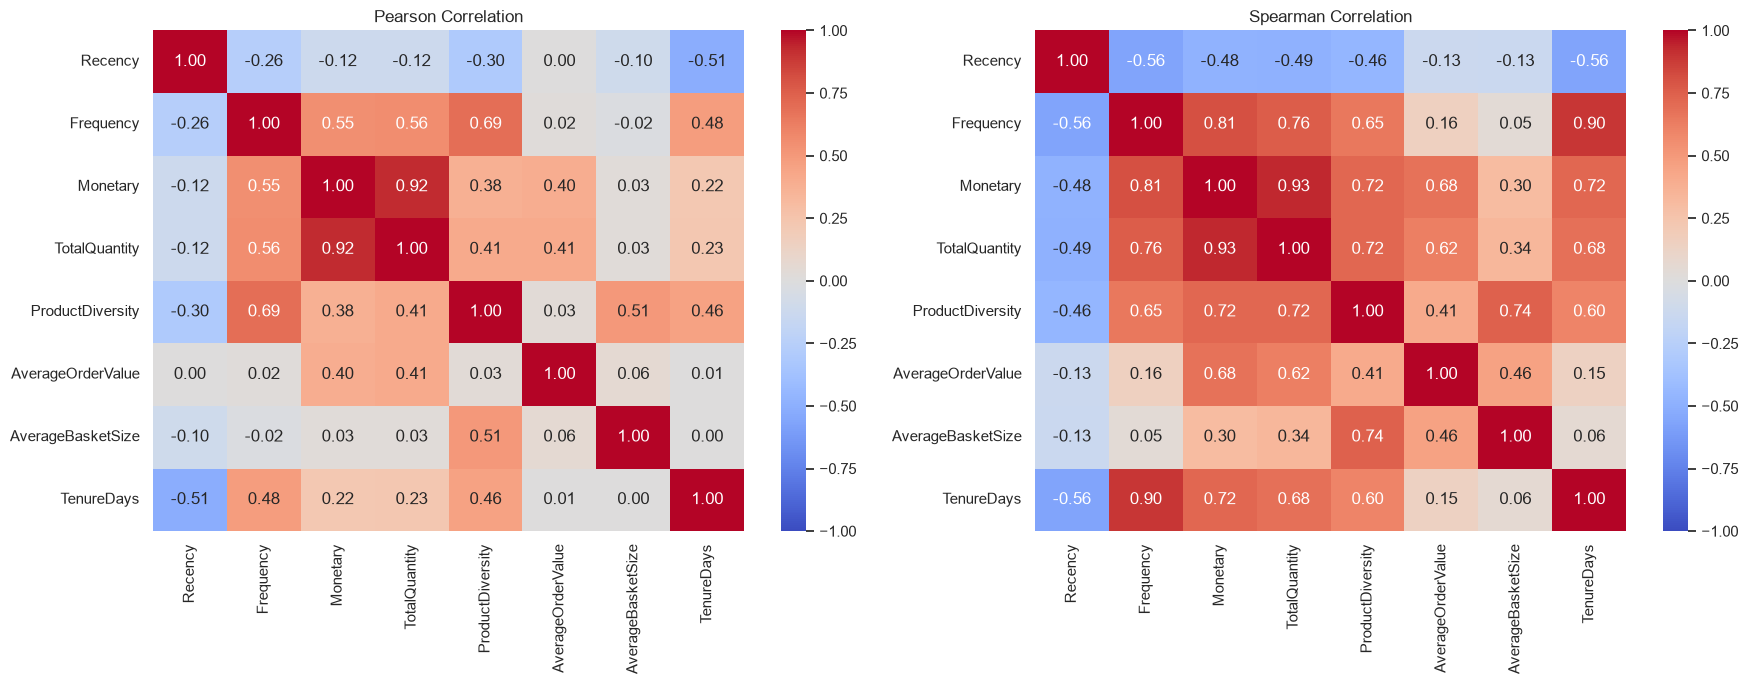

In [13]:
correlation_features = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "ProductDiversity",
    "AverageOrderValue",
    "AverageBasketSize",
    "TenureDays"
]

pearson_correlation = customer_features_df[
    correlation_features
].corr(method="pearson")

spearman_correlation = customer_features_df[
    correlation_features
].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    pearson_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[0]
)
axes[0].set_title("Pearson Correlation")

sns.heatmap(
    spearman_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[1]
)
axes[1].set_title("Spearman Correlation")

plt.tight_layout()
plt.show()

In [14]:
def high_correlation_pairs(correlation_matrix, threshold=0.80):
    pairs = []

    columns = correlation_matrix.columns

    for row_index in range(len(columns)):
        for column_index in range(row_index + 1, len(columns)):
            correlation_value = correlation_matrix.iloc[
                row_index,
                column_index
            ]

            if abs(correlation_value) >= threshold:
                pairs.append({
                    "Feature_1": columns[row_index],
                    "Feature_2": columns[column_index],
                    "Correlation": correlation_value,
                    "Absolute_Correlation": abs(correlation_value)
                })

    return (
        pd.DataFrame(pairs)
        .sort_values(
            "Absolute_Correlation",
            ascending=False
        )
        if pairs
        else pd.DataFrame(
            columns=[
                "Feature_1",
                "Feature_2",
                "Correlation",
                "Absolute_Correlation"
            ]
        )
    )


high_pearson_pairs = high_correlation_pairs(
    pearson_correlation
)

high_spearman_pairs = high_correlation_pairs(
    spearman_correlation
)

print("High Pearson correlation pairs (|r| >= 0.80)")
display(high_pearson_pairs)

print("High Spearman correlation pairs (|rho| >= 0.80)")
display(high_spearman_pairs)

High Pearson correlation pairs (|r| >= 0.80)


,Feature_1,Feature_2,Correlation,Absolute_Correlation
0,Monetary,TotalQuantity,0.92,0.92


High Spearman correlation pairs (|rho| >= 0.80)


,Feature_1,Feature_2,Correlation,Absolute_Correlation
2,Monetary,TotalQuantity,0.93,0.93
1,Frequency,TenureDays,0.90,0.90
0,Frequency,Monetary,0.81,0.81


In [15]:
core_rfm_columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

enhanced_candidate_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "ProductDiversity",
    "AverageBasketSize",
    "TenureDays"
]

diagnostic_only_columns = [
    "TotalQuantity",
    "AverageOrderValue",
    "AverageDaysBetweenPurchases",
    "TransactionRows"
]

print("Core RFM features:")
print(core_rfm_columns)

print("\nEnhanced candidate features:")
print(enhanced_candidate_columns)

print("\nDiagnostic/profiling features:")
print(diagnostic_only_columns)

Core RFM features:
['Recency', 'Frequency', 'Monetary']

Enhanced candidate features:
['Recency', 'Frequency', 'Monetary', 'ProductDiversity', 'AverageBasketSize', 'TenureDays']

Diagnostic/profiling features:
['TotalQuantity', 'AverageOrderValue', 'AverageDaysBetweenPurchases', 'TransactionRows']


In [16]:
log_transform_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "ProductDiversity",
    "AverageOrderValue",
    "AverageBasketSize",
    "TenureDays"
]

log_customer_features_df = customer_features_df.copy()

for column in log_transform_columns:
    log_customer_features_df[f"Log_{column}"] = np.log1p(
        log_customer_features_df[column]
    )

log_feature_summary = pd.DataFrame({
    "Original_Skewness": customer_features_df[
        log_transform_columns
    ].skew(),
    "Log_Skewness": log_customer_features_df[
        [f"Log_{column}" for column in log_transform_columns]
    ].skew().values
})

log_feature_summary["Absolute_Skewness_Reduction"] = (
    log_feature_summary["Original_Skewness"].abs()
    - log_feature_summary["Log_Skewness"].abs()
)

display(log_feature_summary)

,Original_Skewness,Log_Skewness,Absolute_Skewness_Reduction
Recency,1.24,-0.33,0.92
Frequency,11.95,1.21,10.74
Monetary,19.58,0.40,19.18
TotalQuantity,20.41,0.08,20.33
ProductDiversity,6.92,-0.24,6.67
AverageOrderValue,41.46,0.28,41.18
AverageBasketSize,3.29,-0.35,2.94
TenureDays,0.45,-0.39,0.06


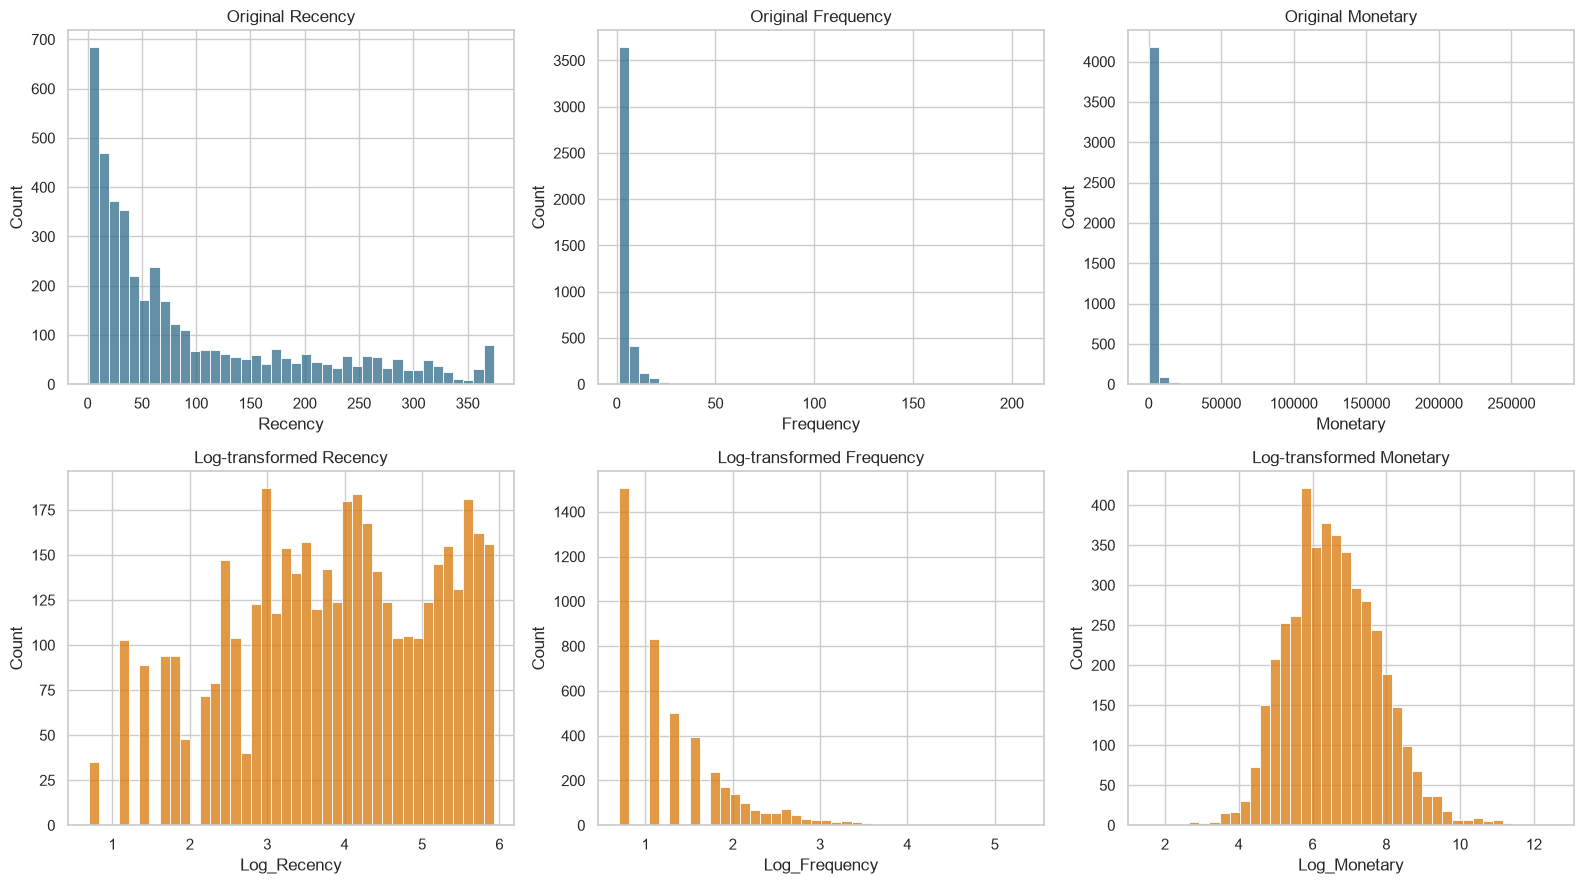

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for index, feature in enumerate(core_rfm_columns):
    sns.histplot(
        customer_features_df[feature],
        bins=40,
        ax=axes[0, index],
        color="#2F6B8A"
    )
    axes[0, index].set_title(f"Original {feature}")

    sns.histplot(
        log_customer_features_df[f"Log_{feature}"],
        bins=40,
        ax=axes[1, index],
        color="#D97706"
    )
    axes[1, index].set_title(f"Log-transformed {feature}")

plt.tight_layout()
plt.show()

### Correlation and Transformation Interpretation

Pearson correlation measures linear relationships and can be strongly affected by extreme values. Spearman correlation evaluates ranked monotonic relationships and is therefore useful for these skewed customer features.

Highly correlated features should not all be used automatically because repeated representations of customer size or activity could receive excessive weight in distance calculations.

The primary feature set remains Recency, Frequency and Monetary because it is established, interpretable and directly aligned with the customer-segmentation objective.

An enhanced candidate set retains Product Diversity, Average Basket Size and Tenure Days for later comparison. Total Quantity, Average Order Value, transaction-line count and average purchase interval are retained mainly for profiling and sensitivity analysis.

Log-transformed alternatives are prepared because several original features are strongly right-skewed. Scaling and final feature-set selection will be performed and compared within the clustering workflow.

## 3. Administrative-Value Sensitivity Analysis

The primary customer features exclude reviewed administrative StockCodes. However, some administrative records may represent genuine customer expenditure, such as postage.

A sensitivity feature is therefore created to measure how customer monetary values change when identified administrative transactions are included. Customers with no merchandise purchases are not introduced into the primary segmentation population.

In [18]:
administrative_path = (
    project_root
    / "data"
    / "processed"
    / "administrative_transactions.csv"
)

assert administrative_path.exists(), (
    "Administrative transaction dataset is missing. "
    "Run notebook 02 first."
)

administrative_df = pd.read_csv(
    administrative_path,
    dtype={
        "InvoiceNo": "string",
        "StockCode": "string",
        "Description": "string",
        "CustomerID": "Int64",
        "Country": "string"
    },
    parse_dates=["InvoiceDate"]
)

print(f"Administrative rows       : {len(administrative_df):,}")
print(
    f"Rows with CustomerID      : "
    f"{administrative_df['CustomerID'].notna().sum():,}"
)
print(
    f"Identified customers      : "
    f"{administrative_df['CustomerID'].nunique():,}"
)

Administrative rows       : 2,310
Rows with CustomerID      : 1,542
Identified customers      : 545


In [19]:
identified_administrative_value = (
    administrative_df.loc[
        administrative_df["CustomerID"].notna()
    ]
    .assign(
        CustomerID=lambda data: (
            data["CustomerID"].astype("int64")
        )
    )
    .groupby("CustomerID")["LineTotal"]
    .sum()
    .rename("AdministrativeValue")
)

monetary_sensitivity_df = (
    customer_features_df[["Monetary"]]
    .join(
        identified_administrative_value,
        how="left"
    )
)

monetary_sensitivity_df["AdministrativeValue"] = (
    monetary_sensitivity_df["AdministrativeValue"]
    .fillna(0)
)

monetary_sensitivity_df["MonetaryWithAdministrative"] = (
    monetary_sensitivity_df["Monetary"]
    + monetary_sensitivity_df["AdministrativeValue"]
)

monetary_sensitivity_df["MonetaryChangePercentage"] = (
    monetary_sensitivity_df["AdministrativeValue"]
    / monetary_sensitivity_df["Monetary"]
    * 100
)

display(monetary_sensitivity_df.head())

,Monetary,AdministrativeValue,MonetaryWithAdministrative,MonetaryChangePercentage
CustomerID,,,,
12346,"77,183.60",0.00,"77,183.60",0.00
12347,"4,310.00",0.00,"4,310.00",0.00
12348,"1,437.24",360.00,"1,797.24",25.05
12349,"1,457.55",300.00,"1,757.55",20.58
12350,294.40,40.00,334.40,13.59


In [20]:
base_rank = (
    monetary_sensitivity_df["Monetary"]
    .rank(method="average", ascending=False)
)

inclusive_rank = (
    monetary_sensitivity_df["MonetaryWithAdministrative"]
    .rank(method="average", ascending=False)
)

rank_correlation = base_rank.corr(
    inclusive_rank,
    method="spearman"
)

administrative_sensitivity_summary = pd.Series({
    "Primary merchandise customers": len(
        monetary_sensitivity_df
    ),
    "Customers with administrative value": (
        monetary_sensitivity_df["AdministrativeValue"] > 0
    ).sum(),
    "Customers without administrative value": (
        monetary_sensitivity_df["AdministrativeValue"] == 0
    ).sum(),
    "Total merchandise monetary value": (
        monetary_sensitivity_df["Monetary"].sum()
    ),
    "Administrative value for primary customers": (
        monetary_sensitivity_df["AdministrativeValue"].sum()
    ),
    "Inclusive monetary value": (
        monetary_sensitivity_df[
            "MonetaryWithAdministrative"
        ].sum()
    ),
    "Median monetary change percentage": (
        monetary_sensitivity_df.loc[
            monetary_sensitivity_df["AdministrativeValue"] > 0,
            "MonetaryChangePercentage"
        ].median()
    ),
    "Maximum monetary change percentage": (
        monetary_sensitivity_df[
            "MonetaryChangePercentage"
        ].max()
    ),
    "Base vs inclusive rank correlation": rank_correlation
}).to_frame("Value")

display(administrative_sensitivity_summary)

,Value
Primary merchandise customers,"4,334.00"
Customers with administrative value,541.00
Customers without administrative value,"3,793.00"
Total merchandise monetary value,"8,737,227.64"
Administrative value for primary customers,"147,016.83"
Inclusive monetary value,"8,884,244.47"
Median monetary change percentage,9.42
Maximum monetary change percentage,412.35
Base vs inclusive rank correlation,1.00


In [21]:
largest_administrative_effects = (
    monetary_sensitivity_df
    .loc[
        monetary_sensitivity_df["AdministrativeValue"] > 0
    ]
    .sort_values(
        "MonetaryChangePercentage",
        ascending=False
    )
    .head(15)
)

display(largest_administrative_effects)

,Monetary,AdministrativeValue,MonetaryWithAdministrative,MonetaryChangePercentage
CustomerID,,,,
15581,717.43,"2,958.34","3,675.77",412.35
15935,108.04,308.82,416.86,285.84
12536,"4,279.71","8,322.12","12,601.83",194.46
12744,"9,120.39","12,158.90","21,279.29",133.32
16257,21.95,25.00,46.95,113.90
12365,320.69,320.69,641.38,100.00
12669,"1,427.73","1,316.30","2,744.03",92.20
12757,"4,176.75","3,657.90","7,834.65",87.58
17940,"2,152.18","1,867.86","4,020.04",86.79


In [22]:
core_rfm_columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

enhanced_feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "ProductDiversity",
    "AverageBasketSize"
]

profiling_columns = [
    "TotalQuantity",
    "AverageOrderValue",
    "TenureDays",
    "AverageDaysBetweenPurchases",
    "TransactionRows",
    "FirstPurchase",
    "LastPurchase",
    "PrimaryCountry"
]

print("Final core RFM feature set:")
print(core_rfm_columns)

print("\nFinal enhanced candidate feature set:")
print(enhanced_feature_columns)

print("\nProfiling and diagnostic variables:")
print(profiling_columns)

Final core RFM feature set:
['Recency', 'Frequency', 'Monetary']

Final enhanced candidate feature set:
['Recency', 'Frequency', 'Monetary', 'ProductDiversity', 'AverageBasketSize']

Profiling and diagnostic variables:
['TotalQuantity', 'AverageOrderValue', 'TenureDays', 'AverageDaysBetweenPurchases', 'TransactionRows', 'FirstPurchase', 'LastPurchase', 'PrimaryCountry']


### Feature-Set and Sensitivity Decision

The primary core feature set contains Recency, Frequency and Monetary. Although Frequency and Monetary have a strong ranked relationship, they represent different and essential RFM dimensions: purchasing activity and customer value.

The enhanced candidate set adds Product Diversity and Average Basket Size. Total Quantity is excluded from clustering candidates because it is highly correlated with Monetary. Tenure Days is retained for profiling because it has a strong ranked relationship with Frequency.

Average Days Between Purchases remains diagnostic because it is naturally undefined for one-purchase customers. Replacing those missing values with zero would create a misleading behavioural meaning.

The merchandise-only Monetary feature remains the primary measure. Monetary including administrative value is retained as a sensitivity alternative because administrative codes mix potentially genuine customer charges with internal adjustments. Final model selection must report whether this choice materially changes cluster quality and customer assignments.

In [23]:
full_customer_features_export = (
    customer_features_df
    .reset_index()
)

core_rfm_raw_df = (
    customer_features_df[
        core_rfm_columns
    ]
    .reset_index()
)

core_rfm_log_df = (
    log_customer_features_df[
        [f"Log_{column}" for column in core_rfm_columns]
    ]
    .reset_index()
)

enhanced_features_raw_df = (
    customer_features_df[
        enhanced_feature_columns
    ]
    .reset_index()
)

enhanced_features_log_df = (
    log_customer_features_df[
        [
            f"Log_{column}"
            for column in enhanced_feature_columns
        ]
    ]
    .reset_index()
)

monetary_sensitivity_export = (
    monetary_sensitivity_df
    .reset_index()
)

print("Feature datasets prepared.")
print(f"Full customer profiles : {len(full_customer_features_export):,}")
print(f"Core RFM rows          : {len(core_rfm_raw_df):,}")
print(f"Enhanced feature rows  : {len(enhanced_features_raw_df):,}")

Feature datasets prepared.
Full customer profiles : 4,334
Core RFM rows          : 4,334
Enhanced feature rows  : 4,334


In [24]:
feature_set_manifest = pd.DataFrame([
    {
        "Feature_Set": "Core RFM Raw",
        "Features": "Recency; Frequency; Monetary",
        "Transformation": "None",
        "Purpose": "Interpretable primary raw feature reference",
        "Downstream_Action": "Scaling required before distance-based clustering"
    },
    {
        "Feature_Set": "Core RFM Log",
        "Features": "Log_Recency; Log_Frequency; Log_Monetary",
        "Transformation": "log1p",
        "Purpose": "Primary clustering candidate with reduced skewness",
        "Downstream_Action": "Compare StandardScaler and RobustScaler"
    },
    {
        "Feature_Set": "Enhanced Raw",
        "Features": "Recency; Frequency; Monetary; ProductDiversity; AverageBasketSize",
        "Transformation": "None",
        "Purpose": "Additional behavioural feature comparison",
        "Downstream_Action": "Scaling required before clustering"
    },
    {
        "Feature_Set": "Enhanced Log",
        "Features": "Log_Recency; Log_Frequency; Log_Monetary; Log_ProductDiversity; Log_AverageBasketSize",
        "Transformation": "log1p",
        "Purpose": "Enhanced clustering candidate with reduced skewness",
        "Downstream_Action": "Compare against Core RFM Log"
    },
    {
        "Feature_Set": "Monetary Sensitivity",
        "Features": "Monetary; AdministrativeValue; MonetaryWithAdministrative; MonetaryChangePercentage",
        "Transformation": "None",
        "Purpose": "Test administrative-value impact",
        "Downstream_Action": "Compare cluster stability where practical"
    }
])

display(feature_set_manifest)

,Feature_Set,Features,Transformation,Purpose,Downstream_Action
0,Core RFM Raw,Recency; Frequency; Monetary,None,Interpretable primary raw feature reference,Scaling required before distance-based clustering
1,Core RFM Log,Log_Recency; Log_Frequency; Log_Monetary,log1p,Primary clustering candidate with reduced skew...,Compare StandardScaler and RobustScaler
2,Enhanced Raw,Recency; Frequency; Monetary; ProductDiversity...,None,Additional behavioural feature comparison,Scaling required before clustering
3,Enhanced Log,Log_Recency; Log_Frequency; Log_Monetary; Log_...,log1p,Enhanced clustering candidate with reduced ske...,Compare against Core RFM Log
4,Monetary Sensitivity,Monetary; AdministrativeValue; MonetaryWithAdm...,None,Test administrative-value impact,Compare cluster stability where practical


In [25]:
feature_output_files = {
    "full_customer_features": (
        processed_path / "full_customer_features.csv"
    ),
    "core_rfm_raw": (
        processed_path / "core_rfm_raw.csv"
    ),
    "core_rfm_log": (
        processed_path / "core_rfm_log.csv"
    ),
    "enhanced_features_raw": (
        processed_path / "enhanced_features_raw.csv"
    ),
    "enhanced_features_log": (
        processed_path / "enhanced_features_log.csv"
    ),
    "monetary_sensitivity": (
        processed_path / "monetary_sensitivity.csv"
    )
}

full_customer_features_export.to_csv(
    feature_output_files["full_customer_features"],
    index=False,
    date_format="%Y-%m-%d %H:%M:%S"
)

core_rfm_raw_df.to_csv(
    feature_output_files["core_rfm_raw"],
    index=False
)

core_rfm_log_df.to_csv(
    feature_output_files["core_rfm_log"],
    index=False
)

enhanced_features_raw_df.to_csv(
    feature_output_files["enhanced_features_raw"],
    index=False
)

enhanced_features_log_df.to_csv(
    feature_output_files["enhanced_features_log"],
    index=False
)

monetary_sensitivity_export.to_csv(
    feature_output_files["monetary_sensitivity"],
    index=False
)

print("Customer feature datasets saved successfully.")

Customer feature datasets saved successfully.


In [26]:
documentation_path = project_root / "documentation"

feature_dictionary.to_csv(
    documentation_path / "feature_dictionary.csv",
    index=False
)

feature_set_manifest.to_csv(
    documentation_path / "feature_set_manifest.csv",
    index=False
)

feature_summary.to_csv(
    documentation_path / "feature_quality_summary.csv"
)

log_feature_summary.to_csv(
    documentation_path / "feature_transformation_summary.csv"
)

administrative_sensitivity_summary.to_csv(
    documentation_path / "administrative_sensitivity_summary.csv"
)

print("Feature-engineering documentation saved successfully.")

Feature-engineering documentation saved successfully.


In [27]:
documentation_path = project_root / "documentation"

feature_dictionary.to_csv(
    documentation_path / "feature_dictionary.csv",
    index=False
)

feature_set_manifest.to_csv(
    documentation_path / "feature_set_manifest.csv",
    index=False
)

feature_summary.to_csv(
    documentation_path / "feature_quality_summary.csv"
)

log_feature_summary.to_csv(
    documentation_path / "feature_transformation_summary.csv"
)

administrative_sensitivity_summary.to_csv(
    documentation_path / "administrative_sensitivity_summary.csv"
)

print("Feature-engineering documentation saved successfully.")

Feature-engineering documentation saved successfully.


In [28]:
feature_fingerprint_records = []

for dataset_name, file_path in feature_output_files.items():
    feature_fingerprint_records.append({
        "Dataset": dataset_name,
        "Filename": file_path.name,
        "Rows": sum(
            1 for _ in open(
                file_path,
                encoding="utf-8"
            )
        ) - 1,
        "File_Size_MB": round(
            file_path.stat().st_size / 1024**2,
            3
        ),
        "SHA256": calculate_sha256(file_path)
    })

feature_fingerprints_df = pd.DataFrame(
    feature_fingerprint_records
)

feature_fingerprints_df.to_csv(
    documentation_path
    / "feature_dataset_fingerprints.csv",
    index=False
)

display(feature_fingerprints_df)

,Dataset,Filename,Rows,File_Size_MB,SHA256
0,full_customer_features,full_customer_features.csv,4334,0.46,00a7043ef143661e749478a235cd59cd17e5fcf9799391...
1,core_rfm_raw,core_rfm_raw.csv,4334,0.08,b2032e4c10668f47c182e23c2a35920c1d611defb44859...
2,core_rfm_log,core_rfm_log.csv,4334,0.25,68790b5095309f4a512800e8eb1e15832153f747a45062...
3,enhanced_features_raw,enhanced_features_raw.csv,4334,0.12,723fd8ad213cb415b8c2187fc8fd7f18a73d2515d6bbd1...
4,enhanced_features_log,enhanced_features_log.csv,4334,0.41,acb152ff272caed7479fb744a95417a3893973a94ff763...
5,monetary_sensitivity,monetary_sensitivity.csv,4334,0.14,b768e37e2307429ff8b9e46dc89a6d357ca8b2740ac94e...


In [30]:
reloaded_core_raw = pd.read_csv(
    feature_output_files["core_rfm_raw"]
)

reloaded_core_log = pd.read_csv(
    feature_output_files["core_rfm_log"]
)

reloaded_enhanced_raw = pd.read_csv(
    feature_output_files["enhanced_features_raw"]
)

reloaded_enhanced_log = pd.read_csv(
    feature_output_files["enhanced_features_log"]
)

reloaded_full_features = pd.read_csv(
    feature_output_files["full_customer_features"],
    parse_dates=["FirstPurchase", "LastPurchase"]
)

assert reloaded_core_raw.shape == (4_334, 4)
assert reloaded_core_log.shape == (4_334, 4)
assert reloaded_enhanced_raw.shape == (4_334, 6)
assert reloaded_enhanced_log.shape == (4_334, 6)
assert len(reloaded_full_features) == 4_334

assert reloaded_core_raw["CustomerID"].is_unique
assert reloaded_core_log["CustomerID"].is_unique
assert reloaded_enhanced_raw["CustomerID"].is_unique
assert reloaded_enhanced_log["CustomerID"].is_unique

assert not reloaded_core_raw.isna().any().any()
assert not reloaded_core_log.isna().any().any()
assert not reloaded_enhanced_raw.isna().any().any()
assert not reloaded_enhanced_log.isna().any().any()

assert np.isfinite(
    reloaded_core_log.select_dtypes(include="number").to_numpy()
).all()

assert np.isfinite(
    reloaded_enhanced_log.select_dtypes(include="number").to_numpy()
).all()

print("All saved customer-feature datasets passed reload validation.")

All saved customer-feature datasets passed reload validation.
